In [2]:
%pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   -----------------

c:\Users\DELL\OneDrive\Documents\ML\venv_n\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:27:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost Results
Accuracy: 0.8114774417451661
ROC-AUC: 0.8340391227911721

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.82      0.89      7482
           1       0.23      0.68      0.35       586

    accuracy                           0.81      8068
   macro avg       0.60      0.75      0.62      8068
weighted avg       0.92      0.81      0.85      8068



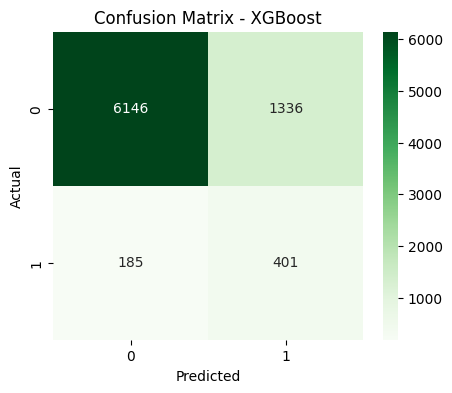

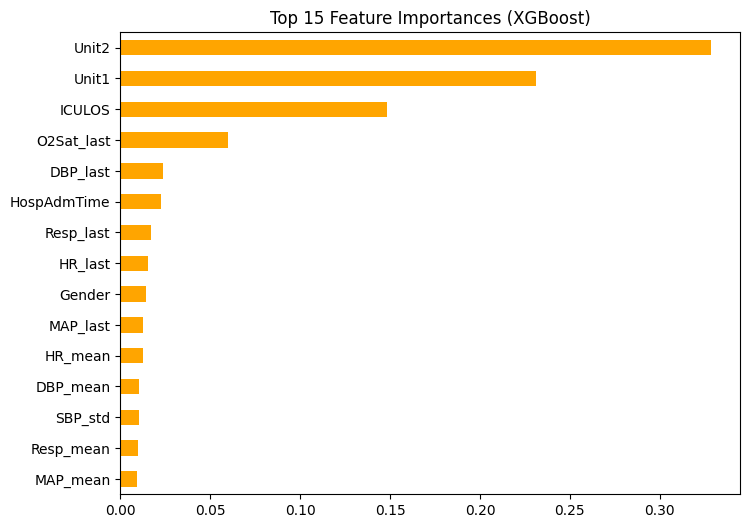

In [34]:
##########         XGBOOST CLASSIFIER
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1️⃣ Read saved data ---
train_data = pd.read_csv("../../data/raw/processed_data/train_resampled.csv")
test_data  = pd.read_csv("../../data/raw/processed_data/test_data.csv")

# --- 2️⃣ Split features and target ---
X_train = train_data.drop(columns=['SepsisLabel'])
y_train = train_data['SepsisLabel']

X_test = test_data.drop(columns=['SepsisLabel'])
y_test = test_data['SepsisLabel']

# --- 3️⃣ Scale the features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4️⃣ Train XGBoost ---
xgb = XGBClassifier(
    n_estimators=3000,
    learning_rate=0.0445,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    # scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),  # handle imbalance
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    use_label_encoder=False
)
xgb.fit(X_train_scaled, y_train)

# --- 5️⃣ Predict and evaluate ---
y_pred = xgb.predict(X_test_scaled)
y_proba = xgb.predict_proba(X_test_scaled)[:, 1]  # probabilities for class 1

print("✅ XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 6️⃣ Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

# --- 7️⃣ Feature importance ---
importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances[:15].plot(kind='barh', color='orange')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.show()


In [32]:
###### hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    use_label_encoder=False
)

# --- 4️⃣ Phase 1 parameter space ---
param_dist = {
    'n_estimators': [300, 700, 1200, 2000, 2500, 3000, 3200, 3500],
    'learning_rate': [0.005, 0.01, 0.02, 0.03, 0.04, 0.045, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9, 10, 11],
    'subsample' : [0.8, 0.9],
    'colsample_bytree' : [0.7, 0.8, 0.9]
}

# --- 5️⃣ Randomized Search ---
rs = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,                 # number of random combos to test
    scoring='roc_auc',         # AUC is a good metric for classification
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rs.fit(X_train_scaled, y_train)

# --- 6️⃣ Best parameters ---
print("Best Parameters:", rs.best_params_)

# --- 7️⃣ Evaluate on test set ---
best_xgb = rs.best_estimator_
y_pred = best_xgb.predict(X_test_scaled)
y_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

print("✅ XGBoost Phase 1 Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits


c:\Users\DELL\OneDrive\Documents\ML\venv_n\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:24:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.9, 'n_estimators': 3500, 'max_depth': 11, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
✅ XGBoost Phase 1 Results
Accuracy: 0.7882994546355975
ROC-AUC: 0.8313438030568017

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.80      0.87      7482
           1       0.21      0.69      0.32       586

    accuracy                           0.79      8068
   macro avg       0.59      0.74      0.60      8068
weighted avg       0.92      0.79      0.83      8068

